Dataset generated cleanly. Train size: 30, Test size: 6

=== ERROR METRICS COMPARISON ===
                 SMA     SES     ML
MAE (Units)   124.66  105.94  64.45
RMSE (Units)  138.92  122.87  85.43
MAPE (%)       22.96   19.71  11.93


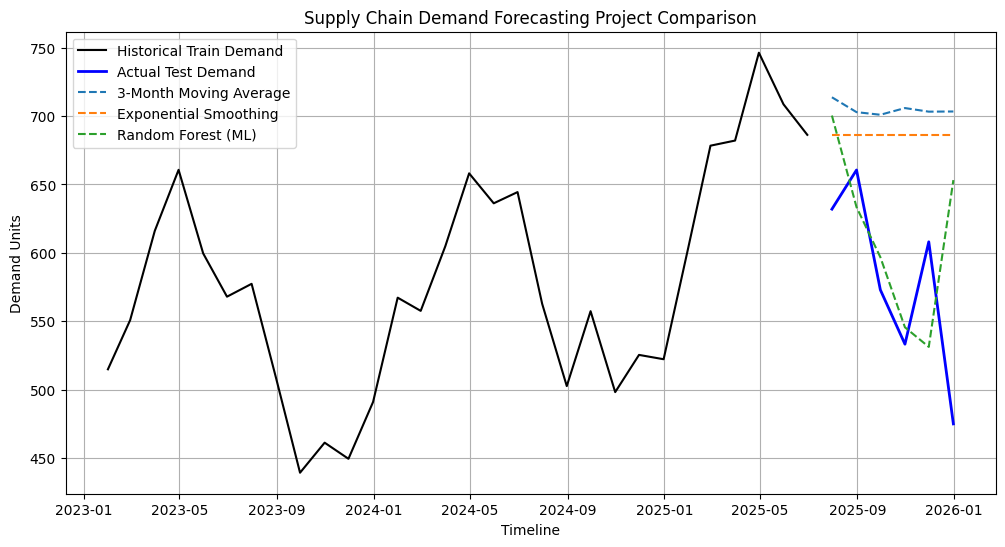

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 1. SETUP & SIMULATE SUPPLY CHAIN DATA
# ==========================================
# Fix the seed for reproducible baseline constraints
np.random.seed(42)


dates = pd.date_range(start='2023-01-01', periods=36, freq='ME')

# Base parameters for demand simulation
base_demand = 500
trend = np.arange(36) * 5
seasonality = np.sin(np.arange(36) * (2 * np.pi / 12)) * 100

# FIX: Ensured the noise dimension matches the 36-period history
noise = np.random.normal(0, 30, 36)
noise[-1] = -150  # Simulate a final-month supply shock anomaly

# Assemble the primary dataframe
df = pd.DataFrame({
    'Date': dates, 
    'Actual_Demand': base_demand + trend + seasonality + noise
})
df.set_index('Date', inplace=True)

# Split into Train (first 30 months) and Test (last 6 months for evaluation)
train = df.iloc[:30].copy()
test = df.iloc[30:].copy()

print(f"Dataset generated cleanly. Train size: {len(train)}, Test size: {len(test)}")

# ==========================================
# 2. MODEL 1: SIMPLE MOVING AVERAGE (SMA)
# ==========================================
window_size = 3
historical_window = list(train['Actual_Demand'].iloc[-window_size:])

sma_forecast = []
for i in range(len(test)):
    next_pred = np.mean(historical_window)
    sma_forecast.append(next_pred)
    historical_window.append(next_pred)
    historical_window.pop(0)

test['SMA_Forecast'] = sma_forecast

# ==========================================
# 3. MODEL 2: EXPONENTIAL SMOOTHING (SES)
# ==========================================
alpha = 0.3
ses_forecast = []
current_level = train['Actual_Demand'].iloc[-1] 

for i in range(len(test)):
    ses_forecast.append(current_level) 
    
test['SES_Forecast'] = ses_forecast

# ==========================================
# 4. MODEL 3: MACHINE LEARNING (Lag-Based)
# ==========================================
ml_df = df.copy()
for lag in range(1, 4):
    ml_df[f'Lag_{lag}'] = ml_df['Actual_Demand'].shift(lag)

ml_df.dropna(inplace=True)

X = ml_df[['Lag_1', 'Lag_2', 'Lag_3']]
y = ml_df['Actual_Demand']

# Syncing ML indices to perfectly isolate test validation metrics
X_train, X_test = X.iloc[:27], X.iloc[27:]
y_train, y_test = y.iloc[:27], y.iloc[27:]

ml_model = RandomForestRegressor(n_estimators=100, random_state=42)
ml_model.fit(X_train, y_train)
test['ML_Forecast'] = ml_model.predict(X_test)

# ==========================================
# 5. ERROR METRICS & MODEL COMPARISON
# ==========================================
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return round(mae, 2), round(rmse, 2), round(mape, 2)

metrics_summary = {}
for model in ['SMA_Forecast', 'SES_Forecast', 'ML_Forecast']:
    metrics_summary[model.replace('_Forecast', '')] = calculate_metrics(test['Actual_Demand'], test[model])

summary_df = pd.DataFrame(metrics_summary, index=['MAE (Units)', 'RMSE (Units)', 'MAPE (%)'])
print("\n=== ERROR METRICS COMPARISON ===")
print(summary_df)

# ==========================================
# 6. VISUALIZE RESULTS
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Actual_Demand'], label='Historical Train Demand', color='black')
plt.plot(test.index, test['Actual_Demand'], label='Actual Test Demand', color='blue', linewidth=2)
plt.plot(test.index, test['SMA_Forecast'], label='3-Month Moving Average', linestyle='--')
plt.plot(test.index, test['SES_Forecast'], label='Exponential Smoothing', linestyle='--')
plt.plot(test.index, test['ML_Forecast'], label='Random Forest (ML)', linestyle='--')

plt.title('Supply Chain Demand Forecasting Project Comparison')
plt.xlabel('Timeline')
plt.ylabel('Demand Units')
plt.legend()
plt.grid(True)
plt.show()